# 9 · Optimized kernels, dispatch, and operator fusion

The first eight tutorials are about *expressing* mathematics. This one is about the
two layers that make that mathematics run fast **without changing how you write
it** — and that both stay out of your way until you ask for them:

* **Optimized-kernel dispatch** ([ADR-016](../../docs/dev/adr/016_kernel_layers.md)) —
  route an operation to the most efficient *bit-exact* array implementation
  (one batched ``matmul`` instead of a per-block loop, for example). It is
  **off by default**: your results never change, and a fast path is taken only
  when you opt in *and* it is provably equivalent.
* **Lazy operator algebra and fusion** ([ADR-021](../../docs/dev/adr/021_lazy_operator_algebra_and_simplification.md)) —
  simplify an *operator expression* and *multiply operators together where
  possible* (collapse ``A @ B @ C`` of dense operators into one matrix). Cheap
  rewrites happen automatically at construction; materializing fusions are an
  **explicit** ``fuse()`` call.

Neither touches the matrix-free contract: a matrix-free operator is never
silently turned into a dense one.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
import spacecore as sc

BLUE, INDIGO, CYAN, SLATE = "#2563eb", "#4338ca", "#0891b2", "#475569"
mpl.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

ctx = sc.Context(sc.NumpyOps(), dtype=np.float64)
rng = np.random.default_rng(0)

## 1 · Two kernel layers

`spacecore.kernels` keeps optimization logic out of the operator classes and
splits it in two:

* **Core kernels** are the check-free bodies of ``apply``/``rapply``/… They are
  bound to each operator *once*, at class-definition time, and are **always on
  the default path** — there is nothing to enable.
* **Benchmarked specs** are heavier fast paths (a batched ``matmul`` over uniform
  dense blocks, an algebraic short-circuit) described by a ``KernelSpec``. They
  are **routed by a single dispatcher**, and dispatch is **off by default**.

Let's build an operator the dispatcher knows a fast path for: a block-diagonal
operator whose blocks are all the same-shape dense matrices.

In [2]:
n, K = 6, 4
X = sc.DenseCoordinateSpace((n,), ctx)
block_mats = [rng.standard_normal((n, n)) for _ in range(K)]
blocks = tuple(sc.DenseLinOp(ctx.asarray(M), X, X, ctx) for M in block_mats)

A = sc.BlockDiagonalLinOp.from_operators(blocks)   # K independent dense blocks
x = tuple(ctx.asarray(rng.standard_normal(n)) for _ in range(K))   # a tree element is just a tuple

y = A.apply(x)            # the default path (core kernel: a per-block loop)
print("blocks      :", K, "x", (n, n))
print("output parts:", [tuple(np.asarray(yi).shape) for yi in y])

blocks      : 4 x (6, 6)
output parts: [(6,), (6,), (6,), (6,)]


### Turning dispatch on

The dispatcher has three modes, set process-globally or — better — for an
enclosing scope with the ``dispatch_mode`` context manager:

* ``"off"`` (default) — always run the plain inline path.
* ``"on"`` — route to the applicable optimized spec (here: stack the blocks and
  issue **one** batched ``matmul`` instead of ``K``).
* ``"verify"`` — run *both* the optimized and the inline path and assert they
  agree bit-for-bit, raising on any mismatch. This is the safety net you run in
  tests/CI before trusting a key.

Because every auto-routable spec is required to be **exactly** equivalent
(``rtol == atol == 0``), ``"on"`` is bit-identical to ``"off"`` — it is faster,
not different.

In [3]:
from spacecore.kernels import dispatch_mode

y_off = A.apply(x)                       # default
with dispatch_mode("on"):
    y_on = A.apply(x)                    # routed to the batched-matmul spec
with dispatch_mode("verify"):
    y_ver = A.apply(x)                   # runs both, asserts agreement

exact = all(np.array_equal(np.asarray(a), np.asarray(b)) for a, b in zip(y_off, y_on))
print("on  is bit-exact to off :", exact)
print("verify mode agreed      :", y_ver is not None)

on  is bit-exact to off : True
verify mode agreed      : True


### Why off by default — the rails

Routing to a fast path is only safe behind a set of rails, all enforced by the
``KernelSpec`` contract:

* **Exactness** — only specs with ``rtol == atol == 0`` are auto-routed.
* **A memory gate** — a *materializing* fast path (one that allocates extra, like
  stacking ``K`` block matrices) carries a shape-only cost estimate, and the
  dispatcher selects it only when that estimate fits the backend's free-memory
  budget. *No estimate, no fuse; no budget, no fuse.*
* **Matrix-free safety** — a matrix-free operator is never silently materialized.

Each operation family the dispatcher knows about is a **dispatch key**; many
specs can register under one key, and the dispatcher picks the highest-priority
applicable one. Here is the live catalog:

In [4]:
from spacecore.kernels import registry

for key in sorted(registry.dispatch_keys()):
    names = [s.name for s in registry.dispatch_candidates(key)]
    print(f"{key:34s} -> {', '.join(names)}")

linop.block_diagonal.apply         -> block-diagonal-uniform-dense-batched
linop.block_diagonal.rapply        -> block-diagonal-uniform-dense-batched-rapply
linop.block_diagonal.rvapply       -> block-diagonal-uniform-dense-batched-rvapply
linop.block_diagonal.vapply        -> block-diagonal-uniform-dense-batched-vapply
linop.composed.apply               -> composed-zero-annihilation, composed-identity-elision
linop.stacked.apply                -> stacked-uniform-dense-batched-apply
linop.sum_to_single.rapply         -> sum-to-single-uniform-dense-batched-rapply


The block-diagonal heatmap below is the structure the fast path exploits: ``K``
independent dense blocks on the diagonal, all the same shape, are exactly the
case a single batched ``matmul`` handles in one backend call.

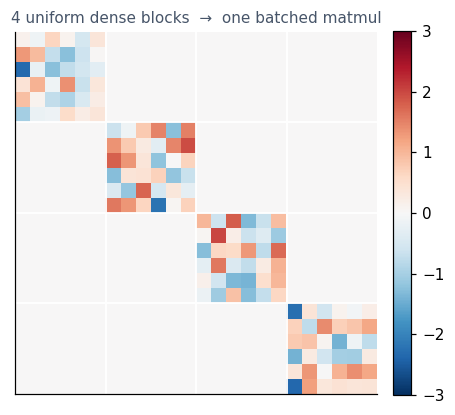

In [5]:
dense_blockdiag = block_diag(*block_mats)
fig, ax = plt.subplots(figsize=(4.2, 4.2))
im = ax.imshow(dense_blockdiag, cmap="RdBu_r", vmin=-3, vmax=3)
ax.set_title(f"{K} uniform dense blocks  →  one batched matmul", fontsize=10, color=SLATE)
for i in range(1, K):
    ax.axhline(i * n - 0.5, color="white", lw=1.2)
    ax.axvline(i * n - 0.5, color="white", lw=1.2)
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

## 2 · Lazy operator algebra and `fuse()`

Operator expressions are **lazy**: ``A @ B``, ``A + B``, ``c * A``, ``A.H`` build
a small tree, evaluating nothing until you apply it. Simplification has two tiers.

**Tier 1 — automatic, at construction.** Cheap, local rewrites happen the moment
you build the expression: an identity factor disappears, a zero map collapses the
product, nested scalars fold. These cost nothing and are always applied.

In [6]:
M1 = sc.DenseLinOp(ctx.asarray(rng.standard_normal((n, n))), X, X, ctx)
I  = sc.IdentityLinOp(X, ctx)

print("M1 @ I  is  M1 :", (M1 @ I) is M1)          # identity elided at construction
print("type of 2*(3*M1):", type(2.0 * (3.0 * M1)).__name__,
      "-> one ScaledLinOp with scalar", (2.0 * (3.0 * M1)).scalar)

M1 @ I  is  M1 : True
type of 2*(3*M1): ScaledLinOp -> one ScaledLinOp with scalar 6.0


**Tier 2 — explicit, with `fuse()`.** *Multiplying operators together* is a
materializing rewrite, so it is something you ask for. ``fuse()`` collapses each
maximal run of dense operators into a single ``DenseLinOp`` holding the matrix
product — the whole chain becomes one matrix.

Fusing reassociates the arithmetic (a matrix product, then apply, differs at the
last bit from applying in sequence), so the result is equal **up to rounding**,
not bit-for-bit. It is adjoint-consistent on any geometry — including
non-Euclidean — because the shared middle-space Riesz maps cancel.

In [7]:
M2 = sc.DenseLinOp(ctx.asarray(rng.standard_normal((n, n))), X, X, ctx)
M3 = sc.DenseLinOp(ctx.asarray(rng.standard_normal((n, n))), X, X, ctx)

expr  = M1 @ M2 @ M3                 # a lazy composition tree
fused = expr.fuse()                  # one DenseLinOp: M1 @ M2 @ M3 as a single matrix

xv = ctx.asarray(rng.standard_normal(n))
print("before fuse :", type(expr).__name__)
print("after  fuse :", type(fused).__name__)
print("same action :", np.allclose(np.asarray(fused.apply(xv)), np.asarray(expr.apply(xv))))

before fuse : ComposedLinOp
after  fuse : DenseLinOp
same action : True


### The matrix-free rail

``fuse()`` only multiplies operators that already hold a cheap matrix. A
**matrix-free** operator — defined by callables, with no stored matrix — is left
untouched: it stays a lazy leaf and simply breaks the fusible run, so its
matrix-free contract is preserved.

If you genuinely want to densify a matrix-free operand — accepting the cost and
giving up the matrix-free property — that is an **explicit opt-in**:
``fuse(materialize=True)``.

In [8]:
Mf = sc.MatrixFreeLinOp(lambda v: 2.0 * v, lambda v: 2.0 * v, X, X, ctx)  # matrix-free

print("(M1 @ Mf).fuse()                 ->", type((M1 @ Mf).fuse()).__name__,
      " (matrix-free kept lazy)")
print("(M1 @ Mf).fuse(materialize=True) ->", type((M1 @ Mf).fuse(materialize=True)).__name__,
      " (explicitly densified)")

(M1 @ Mf).fuse()                 -> ComposedLinOp  (matrix-free kept lazy)
(M1 @ Mf).fuse(materialize=True) -> DenseLinOp  (explicitly densified)


## 3 · How the two layers compose

Fusion changes *what an operator is*; dispatch reads that structure the next time
you apply. So they cooperate: fusing a block whose definition was a composition of
dense operators turns it into a single dense block — which then makes the
enclosing block-diagonal operator eligible for the batched-``matmul`` fast path.

In [9]:
# A block-diagonal whose blocks are themselves compositions of dense operators.
composed_blocks = tuple(
    sc.DenseLinOp(ctx.asarray(rng.standard_normal((n, n))), X, X, ctx)
    @ sc.DenseLinOp(ctx.asarray(rng.standard_normal((n, n))), X, X, ctx)
    for _ in range(K)
)
B = sc.BlockDiagonalLinOp.from_operators(composed_blocks)
B_fused = B.fuse()                  # each block collapses to one DenseLinOp

print("block type before fuse:", type(B.parts[0]).__name__)
print("block type after  fuse:", type(B_fused.parts[0]).__name__,
      "(now foldable by the block-diagonal dispatch spec)")
print("same action           :",
      all(np.allclose(np.asarray(a), np.asarray(b))
          for a, b in zip(B.apply(x), B_fused.apply(x))))

block type before fuse: ComposedLinOp
block type after  fuse: DenseLinOp (now foldable by the block-diagonal dispatch spec)
same action           : True


## Takeaways

* **Dispatch (ADR-016)** picks the fastest *bit-exact* array kernel for an
  operation. It is **off by default**, gated by exactness and a memory budget, and
  never materializes a matrix-free operand. Turn it on with ``dispatch_mode("on")``
  and prove it with ``dispatch_mode("verify")``.
* **Fusion (ADR-021)** simplifies the *operator expression*. Cheap identities fold
  automatically at construction; ``fuse()`` multiplies dense operators into one
  matrix (equal up to rounding, adjoint-consistent on any geometry). It never
  densifies a matrix-free operand unless you pass ``materialize=True``.
* The two **compose**: ``fuse()`` produces operators that dispatch can then
  accelerate.

Both are opt-in by design — the default path always gives you the plain,
predictable result, and the fast paths are there when you ask and only when
they're provably equivalent.